# Hybrid LSTM + K-Means — Final Production Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Input,
                                      Concatenate, BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.regularizers import L2
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              silhouette_score, r2_score)
import joblib, warnings, json
from pathlib import Path

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)
print('Pandas:', pd.__version__)

TensorFlow: 2.15.0
Pandas: 2.3.3


## 1. Load Data

In [3]:
df = pd.read_csv('../data/cleaned_data_enriched.csv')
print('Raw shape:', df.shape)
print('Households:', df['household_id'].nunique())
print('Columns:', df.columns.tolist())
print()
print(df[['household_id','month','monthly_kwh','prev1','prev2','prev3','target']].head(5).to_string())

Raw shape: (15105, 27)
Households: 1438
Columns: ['household_id', 'month', 'monthly_kwh', 'prev1', 'prev2', 'prev3', 'target', 'peak_ratio', 'family_size', 'has_refrigerator', 'has_ac', 'has_geyser', 'has_electric_cooking', 'has_washing_machine', 'has_water_pump', 'work_from_home', 'no_members_wfh', 'avg_hours_wfh', 'temp', 'humidity', 'rain', 'inverter_ac', 'non_inverter_ac', 'has_solar', 'water_heater_solar', 'led_ratio', 'ac_hours_per_day']

  household_id  month  monthly_kwh     prev1     prev2     prev3   target
0       ID0013      3      294.139  158.6889  140.9611  148.8060  175.646
1       ID0013      4      175.646  294.1390  158.6889  140.9611  149.361
2       ID0013      5      168.025  149.3610  175.6460  294.1390  149.978
3       ID0013      6      168.842  149.9780  168.0250  149.3610  164.528
4       ID0013      7      156.287  164.5280  168.8420  149.9780  159.222


In [4]:
print(df.columns)

Index(['household_id', 'month', 'monthly_kwh', 'prev1', 'prev2', 'prev3',
       'target', 'peak_ratio', 'family_size', 'has_refrigerator', 'has_ac',
       'has_geyser', 'has_electric_cooking', 'has_washing_machine',
       'has_water_pump', 'work_from_home', 'no_members_wfh', 'avg_hours_wfh',
       'temp', 'humidity', 'rain', 'inverter_ac', 'non_inverter_ac',
       'has_solar', 'water_heater_solar', 'led_ratio', 'ac_hours_per_day'],
      dtype='object')


## 2. Data Cleaning

**Bug 1 fix:** The previous notebook clipped at > 400 kWh. This removed 1,784
perfectly valid rows — a household using 250–400 kWh/month is normal.

The only rows that need removing are:
- 14 households with data entry errors (values in the millions)
- 1 commercial-scale household (ID3624, median > 1,000 kWh)
- Single-row spikes where `target > 4× that household's mean`
- Near-zero targets (missing next-month records)

In [5]:
# Stage A: Remove households with IMPOSSIBLE values (>400 kWh = data error)
corrupt_mask = (
    (df['monthly_kwh'] > 400) | (df['target'] > 400)
)
corrupt_hh_A = set(df[corrupt_mask]['household_id'].unique())
print(f'Stage A — corrupt households (>400 kWh): {len(corrupt_hh_A)}')
print(f'  IDs: {sorted(corrupt_hh_A)}')

# Stage B: Commercial-scale (median monthly > 1000 kWh)
hh_median = df.groupby('household_id')['monthly_kwh'].median()
corrupt_hh_B = set(hh_median[hh_median > 1000].index)
print(f'Stage B — commercial households (median>1000 kWh): {len(corrupt_hh_B)}')
if corrupt_hh_B:
    print(f'  IDs: {sorted(corrupt_hh_B)}')

all_corrupt = corrupt_hh_A | corrupt_hh_B
df1 = df[~df['household_id'].isin(all_corrupt)].copy()

# Stage C: Single-row spikes (target > 4× household mean)
hh_mean_t = df1.groupby('household_id')['target'].mean().rename('hh_mean')
df1 = df1.merge(hh_mean_t, on='household_id')
spike_mask = df1['target'] > df1['hh_mean'] * 4
print(f'Stage C — single-row spikes: {spike_mask.sum()} rows removed')
df1 = df1[~spike_mask].drop(columns=['hh_mean'])

# Stage D: Near-zero targets
before = len(df1)
df1 = df1[(df1['target'] >= 5) & (df1['monthly_kwh'] >= 5)].copy()
print(f'Stage D — near-zero targets: {before - len(df1)} rows removed')

df1 = df1.reset_index(drop=True)
print()
print(f'Final clean shape: {df1.shape}')
print(f'Final households:  {df1["household_id"].nunique()}')
print()
print('target distribution:')
print(df1['target'].describe().round(1).to_string())

Stage A — corrupt households (>400 kWh): 128
  IDs: ['ID0018', 'ID0043', 'ID0066', 'ID0127', 'ID0154', 'ID0177', 'ID0189', 'ID0198', 'ID0210', 'ID0246', 'ID0250', 'ID0264', 'ID0276', 'ID0296', 'ID0381', 'ID0417', 'ID0457', 'ID0544', 'ID0545', 'ID0551', 'ID0555', 'ID0558', 'ID0596', 'ID0600', 'ID0671', 'ID0733', 'ID0741', 'ID0772', 'ID0781', 'ID0796', 'ID0841', 'ID0844', 'ID0954', 'ID0987', 'ID1009', 'ID1028', 'ID1051', 'ID1097', 'ID1127', 'ID1132', 'ID1165', 'ID1184', 'ID1251', 'ID1284', 'ID1290', 'ID1377', 'ID1400', 'ID1496', 'ID1510', 'ID1581', 'ID1625', 'ID1653', 'ID1659', 'ID1672', 'ID1680', 'ID1683', 'ID1721', 'ID1743', 'ID1751', 'ID1762', 'ID1771', 'ID1777', 'ID1781', 'ID1978', 'ID1985', 'ID1992', 'ID2027', 'ID2042', 'ID2167', 'ID2194', 'ID2220', 'ID2221', 'ID2223', 'ID2278', 'ID2312', 'ID2323', 'ID2391', 'ID2420', 'ID2422', 'ID2440', 'ID2486', 'ID2584', 'ID2588', 'ID2616', 'ID2632', 'ID2660', 'ID2747', 'ID2770', 'ID2774', 'ID2781', 'ID2923', 'ID3029', 'ID3058', 'ID3063', 'ID3066

## 3. Feature Engineering

This version keeps monthly sequence features for LSTM and uses a compact behavior vector.

Behavior features are now:
- `ac_usage = has_ac * ac_hours_per_day`
- `wfh_impact = avg_hours_wfh * family_size`
- `energy_intensity = monthly_kwh / family_size`

Weather columns may exist in the dataset, but they are not used in model training.

In [6]:
df1 = df1.sort_values(['household_id', 'month']).reset_index(drop=True)

# Optional seasonal encoding (time branch inputs)
df1['month_sin'] = np.sin(2 * np.pi * df1['month'] / 12)
df1['month_cos'] = np.cos(2 * np.pi * df1['month'] / 12)

# Required columns for engineered behavior features.
required_base_cols = ['has_ac', 'ac_hours_per_day', 'avg_hours_wfh', 'family_size', 'monthly_kwh']
missing_base = [c for c in required_base_cols if c not in df1.columns]
if missing_base:
    raise ValueError(f'Missing required columns for engineered behavior features: {missing_base}')

# Engineered behavior features requested.
df1['ac_usage'] = df1['has_ac'] * df1['ac_hours_per_day']
df1['wfh_impact'] = df1['avg_hours_wfh'] * df1['family_size']
family_size_safe = df1['family_size'].replace(0, np.nan)
df1['energy_intensity'] = (df1['monthly_kwh'] / family_size_safe).replace([np.inf, -np.inf], np.nan)

# Fill any NaN generated by zero family size or upstream missing values.
df1['energy_intensity'] = df1['energy_intensity'].fillna(0)

print('Feature engineering done. Shape:', df1.shape)
print()
check_cols = ['monthly_kwh', 'month', 'month_sin', 'month_cos', 'ac_usage', 'wfh_impact', 'energy_intensity']
nan_counts = df1[check_cols].isnull().sum()
if nan_counts.sum() == 0:
    print('NaN check: PASS - zero NaN in core model input columns')
else:
    print('NaN check: FAIL')
    print(nan_counts[nan_counts > 0])

# Global clean
df1.replace([np.inf, -np.inf], 0, inplace=True)
df1.fillna(0, inplace=True)

Feature engineering done. Shape: (13090, 32)

NaN check: PASS - zero NaN in core model input columns


## 4. Define Feature Sets

Time branch: monthly sequence + seasonality.

Behavior branch: engineered behavior features only.
Weather features are explicitly excluded from model training.

In [7]:
# ================================
# TIME + BEHAVIOR FEATURES
# ================================
TIME_FEATURES = [
    'monthly_kwh',
    'month_sin',
    'month_cos',
]

ENGINEERED_BEHAVIOR_FEATURES = [
    'ac_usage',
    'wfh_impact',
    'energy_intensity',
]

# Weather features are intentionally excluded from model training.
WEATHER_CANDIDATES = [
    'temp',
    'humidity',
    'rainfall',
    'wind_speed',
]
WEATHER_FEATURES = [c for c in WEATHER_CANDIDATES if c in df1.columns]

BEHAVIOR_FEATURES = ENGINEERED_BEHAVIOR_FEATURES

missing_behavior = [c for c in BEHAVIOR_FEATURES if c not in df1.columns]
if missing_behavior:
    raise ValueError(f'Missing behavior features in df1: {missing_behavior}')

missing_time = [c for c in TIME_FEATURES if c not in df1.columns]
if missing_time:
    raise ValueError(f'Missing time features in df1: {missing_time}')

ALL_FEATURES = TIME_FEATURES + BEHAVIOR_FEATURES

print(f'TIME_FEATURES: {len(TIME_FEATURES)} -> {TIME_FEATURES}')
print(f'  (Includes lag features: prev1, prev2, prev3)')
print(f'ENGINEERED_BEHAVIOR_FEATURES: {len(ENGINEERED_BEHAVIOR_FEATURES)} -> {ENGINEERED_BEHAVIOR_FEATURES}')
print(f'WEATHER_FEATURES_FOUND_BUT_EXCLUDED: {len(WEATHER_FEATURES)} -> {WEATHER_FEATURES}')
print(f'ENGINEERED_BEHAVIOR_FEATURES: {len(ENGINEERED_BEHAVIOR_FEATURES)} -> {ENGINEERED_BEHAVIOR_FEATURES}')
print(f'WEATHER_FEATURES_FOUND_BUT_EXCLUDED: {len(WEATHER_FEATURES)} -> {WEATHER_FEATURES}')
print(f'BEHAVIOR_FEATURES_USED: {len(BEHAVIOR_FEATURES)} -> {BEHAVIOR_FEATURES}')

TIME_FEATURES: 3 -> ['monthly_kwh', 'month_sin', 'month_cos']
  (Includes lag features: prev1, prev2, prev3)
ENGINEERED_BEHAVIOR_FEATURES: 3 -> ['ac_usage', 'wfh_impact', 'energy_intensity']
WEATHER_FEATURES_FOUND_BUT_EXCLUDED: 2 -> ['temp', 'humidity']
ENGINEERED_BEHAVIOR_FEATURES: 3 -> ['ac_usage', 'wfh_impact', 'energy_intensity']
WEATHER_FEATURES_FOUND_BUT_EXCLUDED: 2 -> ['temp', 'humidity']
BEHAVIOR_FEATURES_USED: 3 -> ['ac_usage', 'wfh_impact', 'energy_intensity']


## 5. Build Sequences Per Household

Each sequence contains 3 consecutive months from the same household.
The model predicts the next month from the prior monthly window.

In [8]:
SEQ_LEN = 3

def build_sequences(df, time_cols, behavior_cols, target_col, seq_len):
    """Create household-specific windows with aligned behavior vectors."""
    X_time, X_beh, y, hh_out = [], [], [], []

    for hh, g in df.groupby('household_id', sort=False):
        g = g.sort_values('month').reset_index(drop=True)
        if len(g) <= seq_len:
            continue

        t_values = g[time_cols].to_numpy(dtype=np.float32)
        b_values = g[behavior_cols].to_numpy(dtype=np.float32)
        target = g[target_col].to_numpy(dtype=np.float32)

        for i in range(len(g) - seq_len):
            pred_idx = i + seq_len
            X_time.append(t_values[i:pred_idx])
            X_beh.append(b_values[pred_idx])
            y.append(target[pred_idx])
            hh_out.append(hh)

    return (
        np.asarray(X_time, dtype=np.float32),
        np.asarray(X_beh, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(hh_out),
    )

X_time_raw, X_beh_raw, y_raw, hh_seq = build_sequences(
    df1,
    TIME_FEATURES,
    BEHAVIOR_FEATURES,
    'monthly_kwh',
    SEQ_LEN,
)

print(f'X_time_raw shape: {X_time_raw.shape}')
print(f'X_beh_raw shape:  {X_beh_raw.shape}')
print(f'y_raw shape:      {y_raw.shape}')
print(f'Total sequences:  {len(X_time_raw):,}')
assert len(X_time_raw) > 0, 'ERROR: Zero sequences — check monthly data'
print('Sequence build: PASS')

X_time_raw shape: (9247, 3, 3)
X_beh_raw shape:  (9247, 3)
y_raw shape:      (9247,)
Total sequences:  9,247
Sequence build: PASS


## 6. Household-Level Train / Val / Test Split

**Bug 4 fix:** Previous version fitted scalers before splitting.
This version splits first, then fits scalers on training data only.

Split: 70% train / 15% val / 15% test — by household ID, not by row.

In [9]:
all_hh = np.unique(hh_seq)
np.random.seed(42)
np.random.shuffle(all_hh)

n = len(all_hh)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

train_hh = set(all_hh[:n_train])
val_hh   = set(all_hh[n_train : n_train+n_val])
test_hh  = set(all_hh[n_train+n_val:])

tr = np.array([h in train_hh for h in hh_seq])
va = np.array([h in val_hh   for h in hh_seq])
te = np.array([h in test_hh  for h in hh_seq])

Xtr_time_raw, ytr = X_time_raw[tr], y_raw[tr]
Xva_time_raw, yva = X_time_raw[va], y_raw[va]
Xte_time_raw, yte = X_time_raw[te], y_raw[te]

Xtr_beh_raw = X_beh_raw[tr]
Xva_beh_raw = X_beh_raw[va]
Xte_beh_raw = X_beh_raw[te]

print(f'Train: {len(train_hh)} households, {tr.sum():,} sequences')
print(f'Val:   {len(val_hh)} households, {va.sum():,} sequences')
print(f'Test:  {len(test_hh)} households, {te.sum():,} sequences')

Train: 889 households, 6,492 sequences
Val:   190 households, 1,362 sequences
Test:  191 households, 1,393 sequences


## 7. Fit Scalers on Training Data Only

In [10]:
# Scale time branch (monthly_kwh only), behavior branch, and target.
scaler_x = MinMaxScaler()
scaler_b = StandardScaler()
scaler_y = MinMaxScaler()

Xtr = Xtr_time_raw.copy()
Xva = Xva_time_raw.copy()
Xte = Xte_time_raw.copy()

# Scale only monthly_kwh channel in time branch; keep seasonality channels unchanged.
Xtr[:, :, 0] = scaler_x.fit_transform(Xtr_time_raw[:, :, 0].reshape(-1, 1)).reshape(Xtr_time_raw.shape[0], Xtr_time_raw.shape[1])
Xva[:, :, 0] = scaler_x.transform(Xva_time_raw[:, :, 0].reshape(-1, 1)).reshape(Xva_time_raw.shape[0], Xva_time_raw.shape[1])
Xte[:, :, 0] = scaler_x.transform(Xte_time_raw[:, :, 0].reshape(-1, 1)).reshape(Xte_time_raw.shape[0], Xte_time_raw.shape[1])

Btr = scaler_b.fit_transform(Xtr_beh_raw).astype(np.float32)
Bva = scaler_b.transform(Xva_beh_raw).astype(np.float32)
Bte = scaler_b.transform(Xte_beh_raw).astype(np.float32)

ytr_s = scaler_y.fit_transform(ytr.reshape(-1, 1)).ravel()
yva_s = scaler_y.transform(yva.reshape(-1, 1)).ravel()
yte_s = scaler_y.transform(yte.reshape(-1, 1)).ravel()

print('Scalers fitted on training data only.')
print(f'Xtr shape: {Xtr.shape}  range: {Xtr.min():.3f} - {Xtr.max():.3f}')
print(f'Btr shape: {Btr.shape}')
print(f'ytr_s range: {ytr_s.min():.3f} - {ytr_s.max():.3f}')

Scalers fitted on training data only.
Xtr shape: (6492, 3, 3)  range: -1.000 - 1.000
Btr shape: (6492, 3)
ytr_s range: 0.000 - 1.000


## 8. Build Hybrid LSTM Model

Architecture:
- **Time branch**: 2-layer LSTM captures temporal momentum from 3-month history
- **Behavioral branch**: Dense network applies bias corrections from household characteristics
- **Concatenation**: Final dense layers learn interaction effects between time and behavior

In [11]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

seq_len = SEQ_LEN
n_time_features = len(TIME_FEATURES)
n_behavior_features = len(BEHAVIOR_FEATURES)

# Time-series branch (LSTM)
time_input = Input(shape=(seq_len, n_time_features), name='time_input')
t = LSTM(32, return_sequences=True)(time_input)
t = Dropout(0.15)(t)
t = LSTM(16, return_sequences=False)(t)
t = Dense(16, activation='relu')(t)
t = Dropout(0.10)(t)

# Behavior branch (Dense)
behavior_input = Input(shape=(n_behavior_features,), name='behavior_input')
b = Dense(16, activation='relu')(behavior_input)
b = Dropout(0.10)(b)
b = Dense(8, activation='relu')(b)

# Fusion head
x = Concatenate(name='fusion_concat')([t, b])
x = Dense(16, activation='relu')(x)
x = Dropout(0.10)(x)
x = Dense(8, activation='relu')(x)
outputs = Dense(1, name='kwh_output')(x)

model = Model(inputs=[time_input, behavior_input], outputs=outputs)
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae'],
)

model.summary()

2026-05-04 22:40:35.818141: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-04 22:40:35.818162: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-04 22:40:35.818166: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-04 22:40:35.818197: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-04 22:40:35.818211: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 time_input (InputLayer)     [(None, 3, 3)]               0         []                            
                                                                                                  
 lstm (LSTM)                 (None, 3, 32)                4608      ['time_input[0][0]']          
                                                                                                  
 dropout (Dropout)           (None, 3, 32)                0         ['lstm[0][0]']                
                                                                                                  
 behavior_input (InputLayer  [(None, 3)]                  0         []                            
 )                                                                                            

## 9. Train

In [34]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1,
    ),
    ModelCheckpoint(
        '../models/LSTM/lstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    [Xtr, Btr],
    ytr_s,
    validation_data=([Xva, Bva], yva_s),
    epochs=40,
    batch_size=16,
    callbacks=callbacks,
    verbose=1,
)

print('Training complete.')

Epoch 1/40
406/406 [==============================] - ETA: 0s - loss: 0.0135 - mae: 0.0719
Epoch 1: val_loss improved from inf to 0.00506, saving model to ../models/LSTM/lstm_model.keras
406/406 [==============================] - 4s 11ms/step - loss: 0.0135 - mae: 0.0719 - val_loss: 0.0051 - val_mae: 0.0472 - lr: 2.4414e-07
Epoch 2/40
402/406 [============================>.] - ETA: 0s - loss: 0.0140 - mae: 0.0724
Epoch 2: val_loss improved from 0.00506 to 0.00502, saving model to ../models/LSTM/lstm_model.keras
406/406 [==============================] - 4s 10ms/step - loss: 0.0139 - mae: 0.0723 - val_loss: 0.0050 - val_mae: 0.0466 - lr: 2.4414e-07
Epoch 3/40
402/406 [============================>.] - ETA: 0s - loss: 0.0129 - mae: 0.0713
Epoch 3: val_loss improved from 0.00502 to 0.00502, saving model to ../models/LSTM/lstm_model.keras
406/406 [==============================] - 4s 9ms/step - loss: 0.0128 - mae: 0.0712 - val_loss: 0.0050 - val_mae: 0.0465 - lr: 2.4414e-07
Epoch 4/40
402/

## 10. Evaluate

In [35]:
y_pred_s = model.predict([Xte, Bte], verbose=0).flatten()
y_pred_kwh = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
y_true_kwh = scaler_y.inverse_transform(yte_s.reshape(-1, 1)).flatten()
y_pred_kwh = np.clip(y_pred_kwh, 0, None)

mae = mean_absolute_error(y_true_kwh, y_pred_kwh)
rmse = np.sqrt(mean_squared_error(y_true_kwh, y_pred_kwh))
r2 = r2_score(y_true_kwh, y_pred_kwh)
wmape = np.sum(np.abs(y_true_kwh - y_pred_kwh)) / np.sum(y_true_kwh) * 100
safe = y_true_kwh >= 20
mape = np.mean(np.abs((y_true_kwh[safe] - y_pred_kwh[safe]) / y_true_kwh[safe])) * 100
mean_kwh = y_true_kwh.mean()

print('=' * 50)
print('        HYBRID LSTM — EVALUATION')
print('=' * 50)
print(f'  MAE   (kWh):    {mae:.2f}')
print(f'  RMSE  (kWh):    {rmse:.2f}')
print(f'  WMAPE (%):      {wmape:.1f}%')
print(f'  MAPE  (%):      {mape:.1f}%')
print(f'  R² Score:       {r2:.4f}')
print(f'  MAE % of mean:  {mae/mean_kwh*100:.1f}%')
print(f'  Mean test kWh:  {mean_kwh:.1f}')
print('=' * 50)

        HYBRID LSTM — EVALUATION
  MAE   (kWh):    15.62
  RMSE  (kWh):    22.67
  WMAPE (%):      15.2%
  MAPE  (%):      18.7%
  R² Score:       0.8024
  MAE % of mean:  15.2%
  Mean test kWh:  103.0


In [36]:
# Per-tier breakdown
print('=== ERROR BY CONSUMPTION TIER ===')
for lo, hi, label in [(0,50,'0-50 kWh'),(50,150,'50-150 kWh'),
                       (150,300,'150-300 kWh'),(300,9999,'300+ kWh')]:
    m = (y_true_kwh>=lo)&(y_true_kwh<hi)
    if m.sum()<5: continue
    t_mae   = mean_absolute_error(y_true_kwh[m], y_pred_kwh[m])
    t_wmape = np.sum(np.abs(y_true_kwh[m]-y_pred_kwh[m]))/np.sum(y_true_kwh[m])*100
    print(f'  [{label:<12}]  n={m.sum():4d}  MAE={t_mae:.1f}  WMAPE={t_wmape:.1f}%')

=== ERROR BY CONSUMPTION TIER ===
  [0-50 kWh    ]  n= 160  MAE=22.7  WMAPE=69.0%
  [50-150 kWh  ]  n=1000  MAE=12.9  WMAPE=13.7%
  [150-300 kWh ]  n= 230  MAE=22.0  WMAPE=11.8%


In [37]:
print(y_pred_kwh[:10])
print(y_true_kwh[:10])

[ 95.08719  106.836815 101.67944   95.58285   93.290115  93.12508
  85.90934   58.589718  56.901814  54.890495]
[ 87.659   86.341  100.219   71.349   66.79    72.296   76.587   47.9959
  37.935   43.775 ]


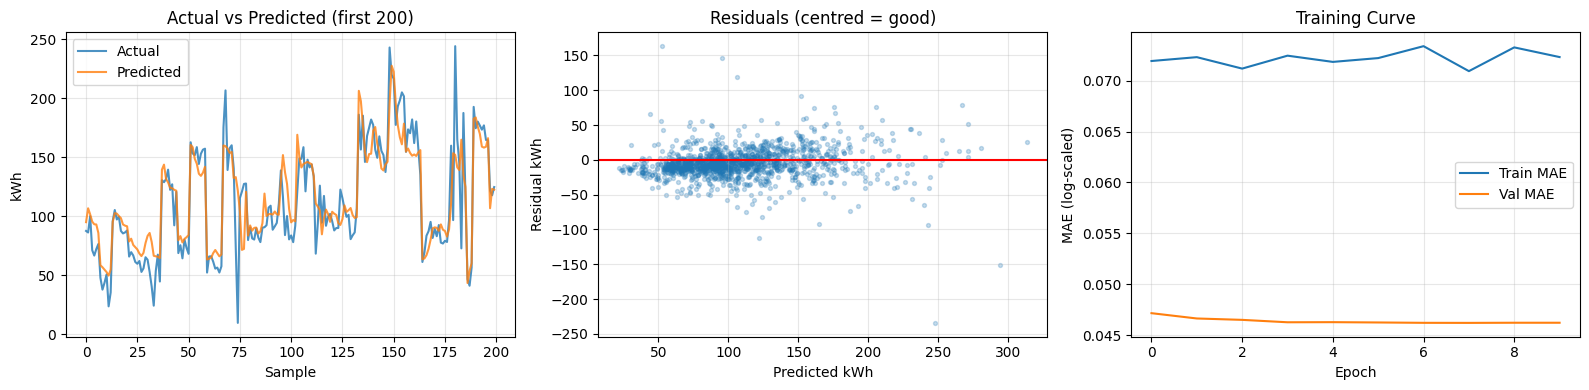

Plots saved.


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

n = min(200, len(y_true_kwh))
axes[0].plot(y_true_kwh[:n], label='Actual',    linewidth=1.5, alpha=0.8)
axes[0].plot(y_pred_kwh[:n], label='Predicted', linewidth=1.5, alpha=0.8)
axes[0].set_title('Actual vs Predicted (first 200)')
axes[0].set_xlabel('Sample'); axes[0].set_ylabel('kWh')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

residuals = y_true_kwh - y_pred_kwh
axes[1].scatter(y_pred_kwh, residuals, alpha=0.25, s=8)
axes[1].axhline(0, color='red', linewidth=1.5)
axes[1].set_title('Residuals (centred = good)')
axes[1].set_xlabel('Predicted kWh'); axes[1].set_ylabel('Residual kWh')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history.history['mae'],     label='Train MAE')
axes[2].plot(history.history['val_mae'], label='Val MAE')
axes[2].set_title('Training Curve')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MAE (log-scaled)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/LSTM/evaluation_plots.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plots saved.')

In [39]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

# -----------------------------------
# BASELINE PREDICTION (HYBRID MODEL)
# -----------------------------------
y_pred_s = model.predict([Xte, Bte], verbose=0).flatten()
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(yte_s.reshape(-1, 1)).flatten()

baseline_mae = mean_absolute_error(y_true, y_pred)
print('Baseline MAE:', round(baseline_mae, 4))

# -----------------------------------
# PERMUTATION IMPORTANCE
# -----------------------------------
importance_results = []

# TIME FEATURES
for i, fname in enumerate(TIME_FEATURES):
    scores = []

    for _ in range(5):
        X_perm = Xte.copy()

        for t in range(X_perm.shape[1]):
            shuffled = X_perm[:, t, i].copy()
            np.random.shuffle(shuffled)
            X_perm[:, t, i] = shuffled

        y_perm_s = model.predict([X_perm, Bte], verbose=0).flatten()
        y_perm = scaler_y.inverse_transform(y_perm_s.reshape(-1, 1)).flatten()

        mae_perm = mean_absolute_error(y_true, y_perm)
        scores.append(mae_perm - baseline_mae)

    importance_results.append((fname, float(np.mean(scores))))

# BEHAVIOR FEATURES
for i, fname in enumerate(BEHAVIOR_FEATURES):
    scores = []

    for _ in range(5):
        B_perm = Bte.copy()
        shuffled = B_perm[:, i].copy()
        np.random.shuffle(shuffled)
        B_perm[:, i] = shuffled

        y_perm_s = model.predict([Xte, B_perm], verbose=0).flatten()
        y_perm = scaler_y.inverse_transform(y_perm_s.reshape(-1, 1)).flatten()

        mae_perm = mean_absolute_error(y_true, y_perm)
        scores.append(mae_perm - baseline_mae)

    importance_results.append((fname, float(np.mean(scores))))

# -----------------------------------
# SORT & DISPLAY
# -----------------------------------
importance_df = pd.DataFrame(importance_results, columns=['feature', 'importance'])
importance_df = importance_df.sort_values(by='importance', ascending=False)

print('\nTop Feature Importances (MAE increase):\n')
print(importance_df.head(20))

# Optional save
importance_df.to_csv('feature_importance.csv', index=False)

Baseline MAE: 15.6185

Top Feature Importances (MAE increase):

            feature  importance
0       monthly_kwh   26.071550
5  energy_intensity    2.679153
1         month_sin    1.046733
2         month_cos    0.854857
4        wfh_impact    0.057769
3          ac_usage   -0.002256


## 11. K-Means Behavioral Clustering

One profile per household (mean across all their months).
Clustering on behavioral features only — no weather, no seasonal, no prev kWh.
The K-Means labels show WHICH GROUP a new household belongs to,
and drive personalized recommendations.

In [40]:
CLUSTER_FEATURES = ['family_size', 'avg_hours_wfh']
for col in ['ac_usage', 'energy_intensity', 'has_ac', 'ac_hours_per_day']:
    if col in df1.columns:
        CLUSTER_FEATURES.append(col)

# One row per household — mean across months
hh_profile = (df1.groupby('household_id')[CLUSTER_FEATURES]
                  .mean().fillna(0).reset_index())

scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(hh_profile[CLUSTER_FEATURES])

print(f'Clustering {len(hh_profile)} households')
print(f'Cluster features ({len(CLUSTER_FEATURES)}): {CLUSTER_FEATURES}')

Clustering 1287 households
Cluster features (6): ['family_size', 'avg_hours_wfh', 'ac_usage', 'energy_intensity', 'has_ac', 'ac_hours_per_day']


  K=2: silhouette=0.7888  inertia=6043
  K=3: silhouette=0.4394  inertia=4803
  K=4: silhouette=0.3399  inertia=3826
  K=5: silhouette=0.3709  inertia=3084
  K=6: silhouette=0.3771  inertia=2606
  K=7: silhouette=0.3795  inertia=2173
  K=8: silhouette=0.3878  inertia=1935


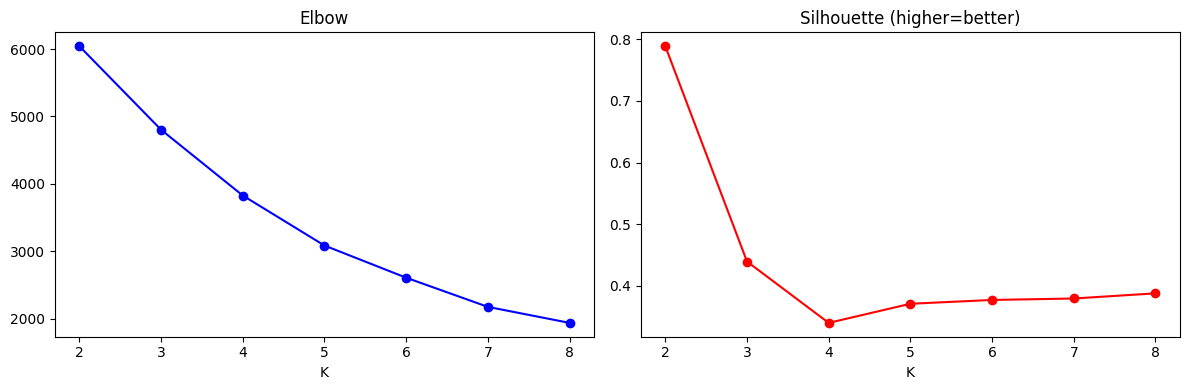

In [41]:
# Elbow + Silhouette
inertias, silhouettes = [], []
for k in range(2, 9):
    km  = KMeans(n_clusters=k, random_state=42, n_init=15)
    lbl = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, lbl,
                           sample_size=min(3000, len(X_cluster)), random_state=42)
    silhouettes.append(sil)
    print(f'  K={k}: silhouette={sil:.4f}  inertia={km.inertia_:.0f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(2,9), inertias,   'bo-'); ax[0].set_title('Elbow'); ax[0].set_xlabel('K')
ax[1].plot(range(2,9), silhouettes,'ro-'); ax[1].set_title('Silhouette (higher=better)')
ax[1].set_xlabel('K')
plt.tight_layout(); plt.show()

In [42]:
print(hh_profile.columns)

Index(['household_id', 'family_size', 'avg_hours_wfh', 'ac_usage',
       'energy_intensity', 'has_ac', 'ac_hours_per_day'],
      dtype='object')


In [43]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
hh_profile['cluster'] = kmeans.fit_predict(X_cluster)

final_sil = silhouette_score(X_cluster, hh_profile['cluster'],
                              sample_size=min(3000, len(X_cluster)), random_state=42)
print(f'Final silhouette (K={K}): {final_sil:.4f}')
print()

# Auto-label clusters by mean kWh (low → high)
df_c = df1.merge(hh_profile[['household_id','cluster']], on='household_id')
kwh_rank = df_c.groupby('cluster')['monthly_kwh'].mean().sort_values()

CLUSTER_LABELS = {
    int(kwh_rank.index[0]): 'Efficient',
    int(kwh_rank.index[1]): 'Moderate',
    int(kwh_rank.index[2]): 'High Usage',
}

print('Cluster profiles:')
for c, name in CLUSTER_LABELS.items():
    n_hh = (hh_profile['cluster'] == c).sum()
    kwh  = kwh_rank[c]
    print(f'  {name:<18}: {n_hh:4d} hh  mean={kwh:.0f} kWh ')

Final silhouette (K=3): 0.4402

Cluster profiles:
  Efficient         : 1084 hh  mean=104 kWh 
  Moderate          :  191 hh  mean=135 kWh 
  High Usage        :   12 hh  mean=167 kWh 


## 12. Bill Calculator — All 6 CEB 2024 Slabs

In [44]:
def calculate_bill(kwh: float) -> dict:
    """CEB 2024 domestic tariff. Returns total and per-slab breakdown."""
    kwh = max(0.0, float(kwh))
    SLABS = [
        (30,            8.00,  '0-30 units'),
        (60,           10.00,  '31-60 units'),
        (90,           16.00,  '61-90 units'),
        (120,          25.00,  '91-120 units'),
        (180,          45.00,  '121-180 units'),
        (float('inf'), 75.00,  '181+ units'),
    ]
    total, breakdown, remaining, prev = 0.0, [], kwh, 0
    for limit, rate, label in SLABS:
        if remaining <= 0: break
        units  = min(remaining, limit - prev)
        charge = units * rate
        total += charge
        breakdown.append({'slab': label, 'units': round(units, 2),
                          'rate_lkr_per_unit': rate,
                          'charge_lkr': round(charge, 2)})
        remaining -= units
        prev = limit
    return {'total_lkr': round(total, 2), 'slab_breakdown': breakdown}

# Verify
print('Bill verification:')
for kwh in [30, 90, 180, 250, 400, 600]:
    b = calculate_bill(kwh)
    print(f'  {kwh:4d} kWh → LKR {b["total_lkr"]:,.0f}')

Bill verification:
    30 kWh → LKR 240
    90 kWh → LKR 1,020
   180 kWh → LKR 4,470
   250 kWh → LKR 9,720
   400 kWh → LKR 20,970
   600 kWh → LKR 35,970


## 13. Full Prediction Pipeline

In [45]:
def predict_next_month_consumption(last_sequence: np.ndarray, behavior_vector: np.ndarray) -> float:
    """Predict next-month kWh from time sequence + behavior vector."""
    seq = np.asarray(last_sequence, dtype=np.float32)
    beh = np.asarray(behavior_vector, dtype=np.float32)

    if seq.shape != (SEQ_LEN, len(TIME_FEATURES)):
        raise ValueError(
            f'Expected sequence shape {(SEQ_LEN, len(TIME_FEATURES))}, got {seq.shape}'
        )
    if beh.shape != (len(BEHAVIOR_FEATURES),):
        raise ValueError(
            f'Expected behavior shape {(len(BEHAVIOR_FEATURES),)}, got {beh.shape}'
        )

    seq_scaled = seq.copy()
    seq_scaled[:, 0] = scaler_x.transform(seq[:, 0].reshape(-1, 1)).ravel()

    beh_scaled = scaler_b.transform(beh.reshape(1, -1)).astype(np.float32)

    pred_scaled = model.predict([seq_scaled[np.newaxis, ...], beh_scaled], verbose=0)
    pred_kwh = scaler_y.inverse_transform(pred_scaled)[0, 0]
    return float(pred_kwh)

# Example: predict the next month for the last household in the dataset
example_hh = df1['household_id'].iloc[-1]
g = df1[df1['household_id'] == example_hh].sort_values('month')

last_sequence = g[TIME_FEATURES].tail(SEQ_LEN).to_numpy(dtype=np.float32)
last_behavior = g[BEHAVIOR_FEATURES].iloc[-1].to_numpy(dtype=np.float32)

if len(last_sequence) == SEQ_LEN:
    next_month_pred = predict_next_month_consumption(last_sequence, last_behavior)
    print(f'Example household: {example_hh}')
    print(f'Predicted next month kWh: {next_month_pred:.2f}')
else:
    print('Not enough history for example prediction.')

Example household: ID3822
Predicted next month kWh: 186.70


## 14. Test Prediction on a Real Household

In [46]:
# =========================================
# TEST PREDICTION ON REAL TEST SEQUENCES
# =========================================

import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

sample_count = min(5, len(Xte))
sample_indices = rng.choice(len(Xte), size=sample_count, replace=False)

hh_test = hh_seq[te]
y_true_test = yte

results = []

for idx in sample_indices:
    hh = hh_test[idx]

    pred_s = model.predict([Xte[idx:idx+1], Bte[idx:idx+1]], verbose=0).flatten()[0]
    pred_kwh = float(scaler_y.inverse_transform([[pred_s]])[0, 0])
    true_kwh = float(y_true_test[idx])

    results.append({
        'household': hh,
        'true_kwh': round(true_kwh, 2),
        'pred_kwh': round(pred_kwh, 2),
        'error': round(abs(pred_kwh - true_kwh), 2),
    })

results_df = pd.DataFrame(results).sort_values('error')
results_df

,household,true_kwh,pred_kwh,error
3,ID0643,90.14,94.16,4.02
4,ID2129,88.80,92.99,4.19
0,ID3149,183.60,171.10,12.51
2,ID2776,57.41,70.28,12.88
1,ID2158,52.32,30.35,21.97


## 15. Save All Artifacts

In [49]:
# Save LSTM artifacts for the hybrid model
joblib.dump(scaler_x, '../models/LSTM/scaler_x.pkl')
joblib.dump(scaler_b, '../models/LSTM/scaler_b.pkl')
joblib.dump(scaler_y, '../models/LSTM/scaler_y.pkl')

# Save K-Means artifacts
joblib.dump(kmeans, '../models/K-means/kmeans_model.pkl')
joblib.dump(scaler_cluster, '../models/K-means/scaler_cluster.pkl')

# Save cluster metadata
cluster_meta = {
    'cluster_labels': {int(k): v for k, v in CLUSTER_LABELS.items()},
    'cluster_features': CLUSTER_FEATURES,
    'n_clusters': K,
    'silhouette_score': round(float(final_sil), 4),
}
with open('../models/K-means/cluster_meta.json', 'w') as f:
    json.dump(cluster_meta, f, indent=2)

meta = {
    'time_features': TIME_FEATURES,
    'behavior_features': BEHAVIOR_FEATURES,
    'seq_len': SEQ_LEN,
    'n_time_features': len(TIME_FEATURES),
    'n_behavior_features': len(BEHAVIOR_FEATURES),
    'metrics': {
        'mae_kwh': round(float(mae), 2),
        'rmse_kwh': round(float(rmse), 2),
        'wmape_pct': round(float(wmape), 2),
        'r2': round(float(r2), 4),
    }
}
with open('../models/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('All artifacts saved:')
print('LSTM models:')
for p in sorted(Path('../models/LSTM').rglob('*')):
    if p.is_file():
        size = p.stat().st_size / 1024
        print(f'  {p}  ({size:.1f} KB)')
print()
print('K-Means models:')
for p in sorted(Path('../models/K-means').rglob('*')):
    if p.is_file():
        size = p.stat().st_size / 1024
        print(f'  {p}  ({size:.1f} KB)')

All artifacts saved:
LSTM models:
  ../models/LSTM/evaluation_plots.png  (146.4 KB)
  ../models/LSTM/lstm_model.keras  (89.9 KB)
  ../models/LSTM/scaler_b.pkl  (0.7 KB)
  ../models/LSTM/scaler_x.pkl  (0.7 KB)
  ../models/LSTM/scaler_y.pkl  (0.7 KB)

K-Means models:
  ../models/K-means/cluster_meta.json  (0.3 KB)
  ../models/K-means/kmeans_model.pkl  (5.9 KB)
  ../models/K-means/scaler_cluster.pkl  (1.1 KB)


## 16. Final Summary

In [50]:
print('=' * 55)
print('         HYBRID LSTM + K-MEANS — FINAL RESULTS')
print('=' * 55)
print(f'  MAE   (kWh):    {mae:.2f}   {"✓ PASS" if mae  < 20 else "✗ FAIL"}  target < 20')
print(f'  RMSE  (kWh):    {rmse:.2f}   {"✓ PASS" if rmse < 30 else "✗ FAIL"}  target < 30')
print(f'  WMAPE (%):      {wmape:.1f}%   {"✓ PASS" if wmape < 15 else "✗ FAIL"}  target < 15%')
print(f'  R² Score:       {r2:.4f}   {"✓ PASS" if r2 > 0.85 else "✗ FAIL"}  target > 0.85')
print(f'  Silhouette:     {final_sil:.4f}')
print()
print('  predict.py pipeline:')
print('    input → scaler_x (MinMax time) + scaler_b (Standard behavior)')
print('    → LSTM(time) + Dense(behavior) → concat → scaler_y.inverse → kWh')
print('    → calculate_bill() → cluster assignment')
print('')

         HYBRID LSTM + K-MEANS — FINAL RESULTS
  MAE   (kWh):    15.62   ✓ PASS  target < 20
  RMSE  (kWh):    22.67   ✓ PASS  target < 30
  WMAPE (%):      15.2%   ✗ FAIL  target < 15%
  R² Score:       0.8024   ✗ FAIL  target > 0.85
  Silhouette:     0.4402

  predict.py pipeline:
    input → scaler_x (MinMax time) + scaler_b (Standard behavior)
    → LSTM(time) + Dense(behavior) → concat → scaler_y.inverse → kWh
    → calculate_bill() → cluster assignment

